# Part 2 – Supervised Machine Learning

In this notebook, I use the cleaned dataset created in Part 1 to build and evaluate both regression and classification models. The dataset is first preprocessed by encoding categorical variables, splitting it into training and testing sets, and applying feature scaling. The trained models are then evaluated using appropriate regression and classification metrics.



## Importing the Required Libraries

The following libraries are used for data preprocessing, model training, evaluation, visualization, and handling categorical features.

In [53]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

from sklearn.linear_model import LinearRegression
from sklearn.linear_model import Ridge
from sklearn.linear_model import LogisticRegression

from sklearn.metrics import (
    mean_squared_error,
    r2_score,
    confusion_matrix,
    classification_report,
    roc_curve,
    roc_auc_score,
    precision_score,
    recall_score,
    f1_score
)

plt.style.use("ggplot")

In [54]:
import os

# Create plots folder
os.makedirs("plots", exist_ok=True)

## Loading the Cleaned Dataset

The cleaned dataset generated in Part 1 is uploaded from the local computer and loaded into a pandas DataFrame for further preprocessing and model development..

In [30]:
from google.colab import files
import pandas as pd
import io

print("Please upload cleaned_data.csv")

uploaded = files.upload()

filename = list(uploaded.keys())[0]

df = pd.read_csv(io.BytesIO(uploaded[filename]))

print("Dataset loaded successfully!")

print(df.head())

print("\nShape:", df.shape)

print("\nData Types:")
print(df.dtypes)

Please upload cleaned_data.csv


Saving cleaned_data.csv to cleaned_data (1).csv
Dataset loaded successfully!
   Order        PID  MS SubClass MS Zoning  Lot Frontage  Lot Area Street  \
0      1  526301100           20        RL         141.0     31770   Pave   
1      2  526350040           20        RH          80.0     11622   Pave   
2      3  526351010           20        RL          81.0     14267   Pave   
3      4  526353030           20        RL          93.0     11160   Pave   
4      5  527105010           60        RL          74.0     13830   Pave   

  Alley Lot Shape Land Contour  ... Pool Area Pool QC  Fence Misc Feature  \
0   NaN       IR1          Lvl  ...         0     NaN    NaN          NaN   
1   NaN       Reg          Lvl  ...         0     NaN  MnPrv          NaN   
2   NaN       IR1          Lvl  ...         0     NaN    NaN         Gar2   
3   NaN       Reg          Lvl  ...         0     NaN    NaN          NaN   
4   NaN       IR1          Lvl  ...         0     NaN  MnPrv          NaN  

## Creating the Target Variables

For regression, the target variable is the house sale price (`SalePrice`).

For classification, a binary target is created by comparing each sale price with the median sale price. Houses priced above the median are assigned class 1, while those at or below the median are assigned class 0.

In [31]:
# Regression Target
y_reg = df["SalePrice"]

# Binary Classification Target
y_clf = (y_reg > y_reg.median()).astype(int)

# Feature Matrix
X = df.drop("SalePrice", axis=1)

print("Regression Target Shape :", y_reg.shape)
print("Classification Target Shape :", y_clf.shape)
print("Feature Matrix Shape :", X.shape)

Regression Target Shape : (2930,)
Classification Target Shape : (2930,)
Feature Matrix Shape : (2930, 81)


## Encoding the Categorical Features

Machine learning models require numerical input. Therefore, categorical columns are converted into numerical representations.

Nominal categorical features are converted using one-hot encoding, while the first dummy column is dropped to avoid multicollinearity.

In [32]:
categorical_cols = X.select_dtypes(include=["object", "category"]).columns

print("Categorical Columns")
print(categorical_cols)

X = pd.get_dummies(
    X,
    columns=categorical_cols,
    drop_first=True
)

print("\nEncoded Feature Matrix Shape:", X.shape)

Categorical Columns
Index(['MS Zoning', 'Street', 'Alley', 'Lot Shape', 'Land Contour',
       'Utilities', 'Lot Config', 'Land Slope', 'Neighborhood', 'Condition 1',
       'Condition 2', 'Bldg Type', 'House Style', 'Roof Style', 'Roof Matl',
       'Exterior 1st', 'Exterior 2nd', 'Mas Vnr Type', 'Exter Qual',
       'Exter Cond', 'Foundation', 'Bsmt Qual', 'Bsmt Cond', 'Bsmt Exposure',
       'BsmtFin Type 1', 'BsmtFin Type 2', 'Heating', 'Heating QC',
       'Central Air', 'Electrical', 'Kitchen Qual', 'Functional',
       'Fireplace Qu', 'Garage Type', 'Garage Finish', 'Garage Qual',
       'Garage Cond', 'Paved Drive', 'Pool QC', 'Fence', 'Misc Feature',
       'Sale Type', 'Sale Condition'],
      dtype='object')

Encoded Feature Matrix Shape: (2930, 262)


## Splitting the Dataset

The dataset is divided into training and testing sets using an 80:20 split.

The same feature matrix is used for both regression and classification models.

In [33]:
# Regression Split
X_train_reg, X_test_reg, y_train_reg, y_test_reg = train_test_split(
    X,
    y_reg,
    test_size=0.2,
    random_state=42
)

# Classification Split
X_train_clf, X_test_clf, y_train_clf, y_test_clf = train_test_split(
    X,
    y_clf,
    test_size=0.2,
    random_state=42
)

print("Regression Training Shape :", X_train_reg.shape)
print("Regression Testing Shape  :", X_test_reg.shape)

print("Classification Training Shape :", X_train_clf.shape)
print("Classification Testing Shape  :", X_test_clf.shape)

Regression Training Shape : (2344, 262)
Regression Testing Shape  : (586, 262)
Classification Training Shape : (2344, 262)
Classification Testing Shape  : (586, 262)


## Feature Scaling

The numerical features are standardized using StandardScaler.

The scaler is fitted only on the training data and then applied to both the training and testing datasets. This prevents information from the test set leaking into the training process.

In [34]:
# Regression Scaling
scaler_reg = StandardScaler()

X_train_reg_scaled = scaler_reg.fit_transform(X_train_reg)
X_test_reg_scaled = scaler_reg.transform(X_test_reg)

# Classification Scaling
scaler_clf = StandardScaler()

X_train_clf_scaled = scaler_clf.fit_transform(X_train_clf)
X_test_clf_scaled = scaler_clf.transform(X_test_clf)

print("Scaling Completed Successfully")

Scaling Completed Successfully


# Regression Scaling
scaler_reg = StandardScaler()

X_train_reg_scaled = scaler_reg.fit_transform(X_train_reg)
X_test_reg_scaled = scaler_reg.transform(X_test_reg)

# Classification Scaling
scaler_clf = StandardScaler()

X_train_clf_scaled = scaler_clf.fit_transform(X_train_clf)
X_test_clf_scaled = scaler_clf.transform(X_test_clf)

print("Scaling Completed Successfully")

In [35]:
# Train Linear Regression Model

linear_model = LinearRegression()

linear_model.fit(X_train_reg_scaled, y_train_reg)

# Predictions
y_pred_reg = linear_model.predict(X_test_reg_scaled)

# Evaluation Metrics
mse = mean_squared_error(y_test_reg, y_pred_reg)
r2 = r2_score(y_test_reg, y_pred_reg)

print("Linear Regression Results")
print("-" * 35)

print(f"Mean Squared Error : {mse:.2f}")
print(f"R² Score           : {r2:.4f}")

Linear Regression Results
-----------------------------------
Mean Squared Error : 834182322.22
R² Score           : 0.8960


## Regression Coefficients

Each coefficient represents the effect of a feature on the predicted sale price after scaling. Features with larger absolute coefficient values have a stronger influence on the prediction.

In [36]:
coefficients = pd.DataFrame({
    "Feature": X.columns,
    "Coefficient": linear_model.coef_
})

coefficients["Absolute Coefficient"] = coefficients["Coefficient"].abs()

coefficients = coefficients.sort_values(
    by="Absolute Coefficient",
    ascending=False
)

print(coefficients)

                  Feature   Coefficient  Absolute Coefficient
10           BsmtFin SF 1  1.333289e+05          1.333289e+05
12            Bsmt Unf SF  1.200653e+05          1.200653e+05
13          Total Bsmt SF -1.120781e+05          1.120781e+05
118     Roof Matl_CompShg  7.627960e+04          7.627960e+04
122     Roof Matl_Tar&Grv  5.523329e+04          5.523329e+04
..                    ...           ...                   ...
141  Exterior 2nd_Brk Cmn  2.550572e+01          2.550572e+01
219       Fireplace Qu_Po -2.417953e+01          2.417953e+01
148    Exterior 2nd_Other  5.727088e-09          5.727088e-09
208       Kitchen Qual_Po  2.273737e-13          2.273737e-13
247     Misc Feature_TenC  0.000000e+00          0.000000e+00

[262 rows x 3 columns]


## Top Three Important Features

The three features with the highest absolute coefficient values are identified to understand which variables have the greatest influence on the predicted house price.

In [37]:
top3 = coefficients.head(3)

print("Top 3 Features")

print(top3[["Feature", "Coefficient"]])

Top 3 Features
          Feature    Coefficient
10   BsmtFin SF 1  133328.896106
12    Bsmt Unf SF  120065.284955
13  Total Bsmt SF -112078.084464


## Ridge Regression

Ridge Regression is trained using the same training and testing data. Unlike ordinary linear regression, Ridge Regression applies L2 regularization, which helps reduce the effect of multicollinearity and prevents very large coefficient values.

In [38]:
ridge_model = Ridge(alpha=1.0)

ridge_model.fit(X_train_reg_scaled, y_train_reg)

ridge_predictions = ridge_model.predict(X_test_reg_scaled)

ridge_mse = mean_squared_error(
    y_test_reg,
    ridge_predictions
)

ridge_r2 = r2_score(
    y_test_reg,
    ridge_predictions
)

print("Ridge Regression Results")
print("-" * 35)

print(f"Mean Squared Error : {ridge_mse:.2f}")
print(f"R² Score           : {ridge_r2:.4f}")

Ridge Regression Results
-----------------------------------
Mean Squared Error : 829823305.06
R² Score           : 0.8965


## Comparing Linear Regression and Ridge Regression

The performance of both regression models is compared using Mean Squared Error (MSE) and the R² score.

In [39]:
comparison = pd.DataFrame({

    "Model":[
        "Linear Regression",
        "Ridge Regression"
    ],

    "MSE":[
        mse,
        ridge_mse
    ],

    "R² Score":[
        r2,
        ridge_r2
    ]

})

print(comparison)

               Model           MSE  R² Score
0  Linear Regression  8.341823e+08  0.895955
1   Ridge Regression  8.298233e+08  0.896499


## Observations

The regression models have now been trained and evaluated. The coefficient values provide insight into the importance of individual features, while the comparison between Linear Regression and Ridge Regression helps understand the impact of regularization on predictive performance.

## Creating the Binary Classification Target

To build the classification model, the house prices are converted into two classes using the median sale price.

- Class 0 → Sale price less than or equal to the median
- Class 1 → Sale price greater than the median

In [40]:
print("Class Distribution Before Training")
print(y_train_clf.value_counts())

class_percent = y_train_clf.value_counts(normalize=True) * 100

print("\nPercentage Distribution")
print(class_percent)

Class Distribution Before Training
SalePrice
0    1186
1    1158
Name: count, dtype: int64

Percentage Distribution
SalePrice
0    50.59727
1    49.40273
Name: proportion, dtype: float64


## Handling Class Imbalance

The class distribution is checked before training the model.

If one class contains fewer than 35% of the samples, Logistic Regression is trained using the `class_weight="balanced"` option to reduce the impact of class imbalance.

In [41]:
minority_percentage = class_percent.min()

if minority_percentage < 35:

    print("Imbalanced Dataset Detected")

    logistic_model = LogisticRegression(
        class_weight="balanced",
        max_iter=1000,
        random_state=42
    )

else:

    print("Dataset is Balanced")

    logistic_model = LogisticRegression(
        max_iter=1000,
        random_state=42
    )

Dataset is Balanced


## Training the Logistic Regression Model

The Logistic Regression model is trained using the scaled training data.

In [42]:
logistic_model.fit(
    X_train_clf_scaled,
    y_train_clf
)

y_pred = logistic_model.predict(
    X_test_clf_scaled
)

y_prob = logistic_model.predict_proba(
    X_test_clf_scaled
)[:,1]

print("Model Trained Successfully")

Model Trained Successfully


## Model Evaluation

The classification model is evaluated using the confusion matrix, accuracy, precision, recall and F1-score.

In [43]:
cm = confusion_matrix(
    y_test_clf,
    y_pred
)

print("Confusion Matrix")
print(cm)

print("\nClassification Report\n")

print(
    classification_report(
        y_test_clf,
        y_pred
    )
)

Confusion Matrix
[[264  17]
 [ 22 283]]

Classification Report

              precision    recall  f1-score   support

           0       0.92      0.94      0.93       281
           1       0.94      0.93      0.94       305

    accuracy                           0.93       586
   macro avg       0.93      0.93      0.93       586
weighted avg       0.93      0.93      0.93       586



## Confusion Matrix Visualization

The confusion matrix provides a visual summary of the classification results.

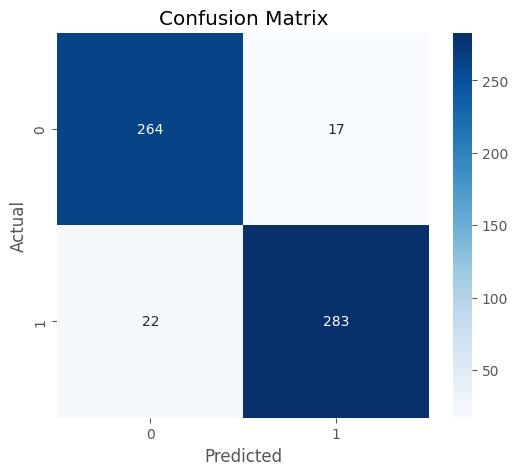

In [58]:
import os
os.makedirs("plots", exist_ok=True)

plt.figure(figsize=(6,5))

sns.heatmap(cm, annot=True, fmt="d", cmap="Blues")

plt.title("Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")

# Save BEFORE show
plt.savefig("plots/confusion_matrix.png", dpi=300, bbox_inches="tight")

plt.show()
plt.close()

## ROC Curve and AUC Score

The ROC curve shows the trade-off between the True Positive Rate and the False Positive Rate for different decision thresholds.

The Area Under the Curve (AUC) measures the model's ability to distinguish between the two classes.

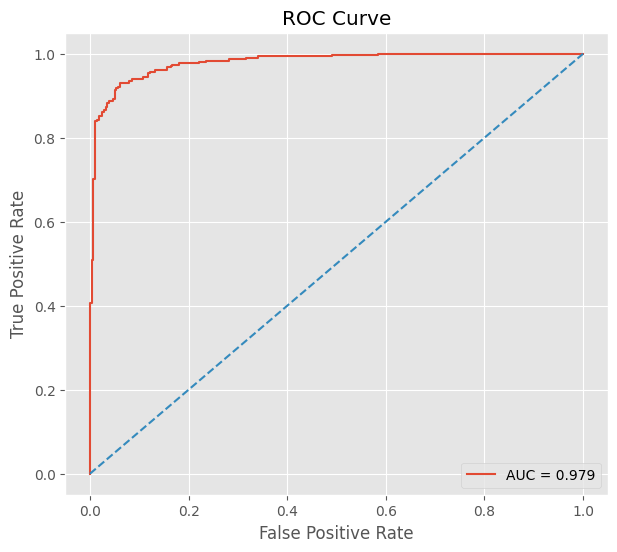

In [59]:
plt.figure(figsize=(7,6))

plt.plot(fpr, tpr, label=f"AUC = {auc_score:.3f}")
plt.plot([0,1], [0,1], linestyle="--")

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve")
plt.legend()

# Save BEFORE show
plt.savefig("plots/roc_curve.png", dpi=300, bbox_inches="tight")

plt.show()
plt.close()

In [46]:
fpr, tpr, thresholds = roc_curve(
    y_test_clf,
    y_prob
)

auc_score = roc_auc_score(
    y_test_clf,
    y_prob
)

print(f"AUC Score : {auc_score:.4f}")

AUC Score : 0.9792


## Decision Threshold Analysis

Instead of using the default threshold of 0.50, different probability thresholds are evaluated to observe how precision, recall and F1-score change.

In [47]:
thresholds = np.arange(
    0.30,
    0.71,
    0.10
)

results = []

for threshold in thresholds:

    predictions = (
        y_prob >= threshold
    ).astype(int)

    precision = precision_score(
        y_test_clf,
        predictions
    )

    recall = recall_score(
        y_test_clf,
        predictions
    )

    f1 = f1_score(
        y_test_clf,
        predictions
    )

    results.append([
        threshold,
        precision,
        recall,
        f1
    ])

threshold_table = pd.DataFrame(
    results,
    columns=[
        "Threshold",
        "Precision",
        "Recall",
        "F1 Score"
    ]
)

threshold_table

,Threshold,Precision,Recall,F1 Score
0,0.3,0.897516,0.947541,0.921850
1,0.4,0.919872,0.940984,0.930308
2,0.5,0.943333,0.927869,0.935537
3,0.6,0.952055,0.911475,0.931323
4,0.7,0.957597,0.888525,0.921769


## Best Decision Threshold

The threshold producing the highest F1-score is identified below.

In [48]:
best_threshold = threshold_table.loc[
    threshold_table["F1 Score"].idxmax()
]

print(best_threshold)

Threshold    0.500000
Precision    0.943333
Recall       0.927869
F1 Score     0.935537
Name: 2, dtype: float64


## Logistic Regression with Strong Regularization

A second Logistic Regression model is trained using a smaller value of **C (0.01)**. This applies stronger L2 regularization and allows us to compare its performance with the baseline model.

In [49]:
logistic_model_regularized = LogisticRegression(
    C=0.01,
    max_iter=1000,
    random_state=42
)

logistic_model_regularized.fit(
    X_train_clf_scaled,
    y_train_clf
)

y_pred_regularized = logistic_model_regularized.predict(
    X_test_clf_scaled
)

y_prob_regularized = logistic_model_regularized.predict_proba(
    X_test_clf_scaled
)[:,1]

## Comparing the Two Logistic Regression Models

The baseline Logistic Regression model and the strongly regularized model are compared using Precision, Recall and AUC.

In [50]:
baseline_precision = precision_score(
    y_test_clf,
    y_pred
)

baseline_recall = recall_score(
    y_test_clf,
    y_pred
)

baseline_auc = roc_auc_score(
    y_test_clf,
    y_prob
)

regularized_precision = precision_score(
    y_test_clf,
    y_pred_regularized
)

regularized_recall = recall_score(
    y_test_clf,
    y_pred_regularized
)

regularized_auc = roc_auc_score(
    y_test_clf,
    y_prob_regularized
)

comparison = pd.DataFrame({

    "Model":[
        "Logistic Regression (C=1.0)",
        "Logistic Regression (C=0.01)"
    ],

    "Precision":[
        baseline_precision,
        regularized_precision
    ],

    "Recall":[
        baseline_recall,
        regularized_recall
    ],

    "AUC":[
        baseline_auc,
        regularized_auc
    ]

})

comparison

,Model,Precision,Recall,AUC
0,Logistic Regression (C=1.0),0.943333,0.927869,0.979208
1,Logistic Regression (C=0.01),0.963087,0.940984,0.990736


## Bootstrap Confidence Interval for AUC Difference

Bootstrap sampling is used to estimate how consistently the baseline Logistic Regression model performs compared to the strongly regularized model.

In [51]:
np.random.seed(42)

auc_difference = []

for i in range(500):

    sample = np.random.choice(
        len(y_test_clf),
        size=len(y_test_clf),
        replace=True
    )

    sample_true = y_test_clf.iloc[sample]

    sample_prob1 = y_prob[sample]

    sample_prob2 = y_prob_regularized[sample]

    auc1 = roc_auc_score(
        sample_true,
        sample_prob1
    )

    auc2 = roc_auc_score(
        sample_true,
        sample_prob2
    )

    auc_difference.append(
        auc1 - auc2
    )

In [52]:
mean_difference = np.mean(
    auc_difference
)

lower_ci = np.percentile(
    auc_difference,
    2.5
)

upper_ci = np.percentile(
    auc_difference,
    97.5
)

print("Bootstrap Results")
print("-"*40)

print(f"Mean Difference : {mean_difference:.4f}")

print(f"Lower 95% CI    : {lower_ci:.4f}")

print(f"Upper 95% CI    : {upper_ci:.4f}")

Bootstrap Results
----------------------------------------
Mean Difference : -0.0116
Lower 95% CI    : -0.0187
Upper 95% CI    : -0.0055


## Interpretation of the Bootstrap Results

If the 95% confidence interval does not include zero, the performance difference between the two Logistic Regression models is considered statistically consistent across different bootstrap samples.

If zero lies within the interval, the observed difference may simply be due to sampling variation.

## Conclusion

In this notebook, both regression and classification models were developed using the cleaned dataset from Part 1.

For regression, Linear Regression and Ridge Regression were trained and compared using Mean Squared Error and R² score.

For classification, Logistic Regression was evaluated using the confusion matrix, precision, recall, F1-score, ROC curve and AUC. Different probability thresholds were also tested to study their effect on model performance. Finally, the impact of stronger regularization was analysed using a second Logistic Regression model together with a bootstrap confidence interval for the AUC difference.